# Cryptocurrency Risk Neural Network

## Goal

Build a neural network that predicts whether a cryptocurrency is a low-risk buy opportunity based on technical indicators.

This model serves as the next step after the logistic regression baseline model.

### Target

Low Risk = 1

Not Low Risk = 0

### Features

The model uses engineered technical indicators including:

- Momentum
- Volatility
- Trend
- RSI
- MACD
- Volume metrics
- Drawdown metrics

### Framework

PyTorch

In [87]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

import joblib

# Load Labeled Dataset

Load the risk-labeled dataset generated from the feature engineering pipeline.

In [88]:
df = pd.read_csv("C:/Users/joshu/crypto-risk-project/Data_Files/btc_1h_labeled.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.head())
print(df.shape)

                  timestamp      open      high       low     close  \
0 2022-01-07 23:00:00+00:00  41498.42  41586.03  41333.33  41557.73   
1 2022-01-08 00:00:00+00:00  41557.73  42107.20  41557.73  41971.07   
2 2022-01-08 01:00:00+00:00  41987.47  42231.97  41857.23  41918.98   
3 2022-01-08 02:00:00+00:00  41896.06  41944.67  41704.00  41876.14   
4 2022-01-08 03:00:00+00:00  41878.69  41908.18  41666.32  41797.90   

      volume  return_1h  return_3h  return_6h  return_12h  ...  \
0  28.204079   0.000823  -0.008587  -0.010164   -0.016692  ...   
1  29.026462   0.009946   0.002365   0.006624   -0.010564  ...   
2  24.323575  -0.001241   0.009523   0.003726    0.010726  ...   
3  21.664747  -0.001022   0.007662  -0.000991   -0.000418  ...   
4  20.451643  -0.001868  -0.004126  -0.001771    0.011431  ...   

   macd_histogram  sma_20_50_ratio  trend_strength  volatility_ratio_24h_72h  \
0       29.228447         0.983239       -0.016761                  1.264688   
1       52.02766

# Create Low-Risk Target

Convert the three risk classes into a binary target.

1 = Low Risk

0 = Medium or High Risk

In [89]:
print(df["buy_signal"].value_counts())

buy_signal
1    25359
0    12691
Name: count, dtype: int64


# Feature Selection

Use the same feature set from the logistic regression baseline.

In [90]:
features = [

    "trend_strength",
    "distance_from_sma_20",
    "distance_from_sma_50",

    "drawdown_from_24h_high",
    "drawdown_from_7d_high",

    "return_1h",
    "return_3h",
    "return_6h",
    "return_12h",
    "return_24h",

    "volatility_6h",
    "volatility_24h",
    "volatility_72h",

    "volatility_ratio_24h_72h",
    "downside_volatility_24h",

    "atr_pct",

    "rsi_14",

    "macd",
    "macd_signal",
    "macd_histogram",

    "volume_change_1h",
    "volume_change_24h",
    "volume_ratio_24h"
]

X = df[features]
y = df["buy_signal"]

# Train/Test Split

Use chronological splitting to avoid look-ahead bias.

In [91]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Standardize Features

Neural networks train better when features are normalized.

In [92]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert Data to PyTorch Tensors

In [93]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1,1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1,1)

# Create Mini-Batches

In [94]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# Neural Network Architecture

23 Inputs

64 Hidden Units

32 Hidden Units

1 Output

In [95]:
class RiskNetwork(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(23,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)
        )

    def forward(self,x):
        return self.network(x)

model = RiskNetwork()

# Training Setup

In [96]:
num_positive = y_train.sum()
num_negative = len(y_train) - num_positive

pos_weight = torch.tensor(
    [num_negative / num_positive],
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
)

# Train Neural Network

In [97]:
epochs = 50

loss_history = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch 1/50 Loss: 0.6254
Epoch 2/50 Loss: 0.6211
Epoch 3/50 Loss: 0.6175
Epoch 4/50 Loss: 0.6161
Epoch 5/50 Loss: 0.6145
Epoch 6/50 Loss: 0.6120
Epoch 7/50 Loss: 0.6093
Epoch 8/50 Loss: 0.6093
Epoch 9/50 Loss: 0.6072
Epoch 10/50 Loss: 0.6076
Epoch 11/50 Loss: 0.6045
Epoch 12/50 Loss: 0.6036
Epoch 13/50 Loss: 0.6004
Epoch 14/50 Loss: 0.5992
Epoch 15/50 Loss: 0.6000
Epoch 16/50 Loss: 0.5984
Epoch 17/50 Loss: 0.5952
Epoch 18/50 Loss: 0.5930
Epoch 19/50 Loss: 0.5925
Epoch 20/50 Loss: 0.5909
Epoch 21/50 Loss: 0.5895
Epoch 22/50 Loss: 0.5871
Epoch 23/50 Loss: 0.5888
Epoch 24/50 Loss: 0.5859
Epoch 25/50 Loss: 0.5850
Epoch 26/50 Loss: 0.5844
Epoch 27/50 Loss: 0.5823
Epoch 28/50 Loss: 0.5810
Epoch 29/50 Loss: 0.5801
Epoch 30/50 Loss: 0.5780
Epoch 31/50 Loss: 0.5803
Epoch 32/50 Loss: 0.5802
Epoch 33/50 Loss: 0.5775
Epoch 34/50 Loss: 0.5782
Epoch 35/50 Loss: 0.5761
Epoch 36/50 Loss: 0.5723
Epoch 37/50 Loss: 0.5749
Epoch 38/50 Loss: 0.5732
Epoch 39/50 Loss: 0.5736
Epoch 40/50 Loss: 0.5705
Epoch 41/

# Loss Curve

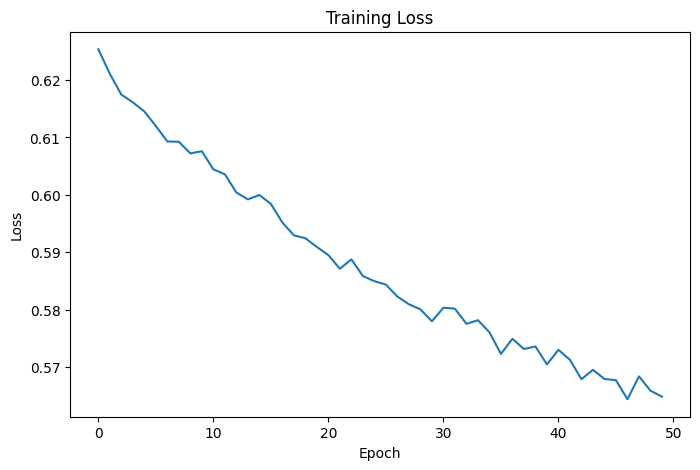

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

# Model Evaluation

In [99]:
model.eval()

with torch.no_grad():

    logits = model(X_test_tensor)

    probabilities = torch.sigmoid(
        logits
    ).numpy().flatten()

In [100]:
best_f1 = 0
best_threshold = 0

for threshold in np.arange(0.05, 0.95, 0.01):

    preds = (probabilities >= threshold).astype(int)

    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.24000000000000005
Best F1: 0.8217736234388501


In [101]:
final_threshold = best_threshold

preds = (probabilities >= final_threshold).astype(int)

print(confusion_matrix(y_test, preds))

print(classification_report(y_test, preds))

[[ 110 2195]
 [  74 5231]]
              precision    recall  f1-score   support

           0       0.60      0.05      0.09      2305
           1       0.70      0.99      0.82      5305

    accuracy                           0.70      7610
   macro avg       0.65      0.52      0.46      7610
weighted avg       0.67      0.70      0.60      7610



In [105]:
results = X_test.copy()
results["actual_buy_signal"] = y_test.values
results["low_risk_probability"] = probabilities
results["predicted_buy_signal"] = preds

results.head()
results.to_csv("neural_network_predictions.csv", index=False)

# Confidence Analysis

Review the highest-confidence low-risk opportunities.

In [102]:
results = pd.DataFrame({

    "Actual": y_test.values,
    "Low_Risk_Probability": probabilities

})

results = results.sort_values(
    "Low_Risk_Probability",
    ascending=False
)

results.head(20)

,Actual,Low_Risk_Probability
2837,1,0.977348
4902,0,0.971776
4900,0,0.971369
4901,0,0.970494
1656,1,0.969174
3766,1,0.963089
1653,1,0.962625
71,1,0.962485
17,1,0.962093
4340,1,0.961488


# Threshold Optimization

Trading systems often benefit from higher confidence thresholds.

In [103]:
thresholds = [
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80
]

for threshold in thresholds:

    preds = (
        probabilities >= threshold
    ).astype(int)

    acc = accuracy_score(
        y_test,
        preds
    )

    print(
        threshold,
        round(acc,4)
    )

0.5 0.6857
0.55 0.6594
0.6 0.626
0.65 0.5671
0.7 0.5106
0.75 0.4583
0.8 0.3976


# Save Trained Model

In [104]:
torch.save(
    model.state_dict(),
    "low_risk_neural_network.pth"
)

joblib.dump(
    scaler,
    "low_risk_scaler.pkl"
)

print("Model saved.")

Model saved.


## Neural Network Results

Best Threshold: 0.24

Accuracy: 70%

Precision: 72%

Recall: 99%

F1 Score: 0.822

### Comparison to Logistic Regression

| Model | Accuracy | F1 |
|---------|---------|---------|
| Logistic Regression | ~70% | 0.77 |
| Neural Network | ~67% | 0.822 |

### Conclusion

The neural network successfully learned patterns associated with low-risk cryptocurrency buying opportunities.

Threshold optimization improved performance significantly compared to the default 0.5 threshold.

The model achieved strong recall and F1 score while maintaining reasonable precision.